#  Exploratory Data Analysis (EDA) Historical Memory Prices
**Dataset:** memory_prices_updated.csv  
**Sumber:** Kaggle / Data Publik  
**Analisis oleh:** Muhammad Fahriel - 2509116050  

---

## Latar Belakang

Dataset ini merekam **harga memori komputer** dari tahun **1957 hingga 2026**, mencakup berbagai jenis memori, produsen, kapasitas (Kbyte), dan kecepatan (nanosecond). Tujuan analisis ini adalah:

1. Memahami tren penurunan harga memori sepanjang dekade
2. Mengidentifikasi perusahaan dan jenis memori yang mendominasi pasar
3. Menganalisis hubungan antara kapasitas, kecepatan, dan harga
4. Menemukan pola atau anomali yang menarik dalam data historis

> **Relevansi:** Dataset ini sangat relevan untuk memahami **Hukum Moore** dan bagaimana teknologi memori berkembang secara eksponensial selama ~70 tahun terakhir.

##  1. Import Library & Mounting File Drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
from google.colab import drive
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("Library berhasil diimport!")

Library berhasil diimport!


In [ ]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/dataset/memory_prices_updated.csv')

print(f" Jumlah baris    : {df.shape[0]}")
print(f" Jumlah kolom    : {df.shape[1]}")
print(f" Rentang tahun   : {df['year'].min()} – {df['year'].max()}")
print()
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Jumlah baris    : 438
 Jumlah kolom    : 12
 Rentang tahun   : 1957 – 2026



,year,day_month,Company,Size in Kbyte,Cost in USD,Speed in nanosec,Memory Type,Ref,Page,JDR Chip Prices - Size Kbit,JDR Chip Prices - USD,JDR Chip Prices - nanosec
0,1957,NaN,C.C.C.,0.000977,392.00,10000,Flip-Flop transistor,Phister 366,366.0,NaN,NaN,NaN
1,1959,NaN,E.E.Co.,0.000977,64.80,10000,Flip-Flop - vacuum tube,Phister 366,366.0,NaN,NaN,NaN
2,1960,NaN,IBM,0.000977,5.00,11500,Core memory for IBM 1401,Phister 367,367.0,NaN,NaN,NaN
3,1965,NaN,IBM,0.000977,2.52,2000,Core Memory for IBM 360/30,Phister 367,367.0,NaN,NaN,NaN
4,1970,NaN,IBM,0.000977,0.70,770,Core Memory for IBM 370/135,Phister 367,367.0,NaN,NaN,NaN
5,1973,Jan,DEC,12.000000,4680.00,NaN,Core memory 8Kwords x 12 bit,PDP8/e User Price List,NaN,NaN,NaN,NaN
6,1974,NaN,IBM,0.000977,0.30,800,IC Memory for IBM 370/125,Phister 367,367.0,NaN,NaN,NaN
7,1975,Jan,MITS,0.250000,103.00,1000,Altair 8800 256 Byte Static Board,Radio-Electronics,NaN,NaN,NaN,NaN
8,1975,Feb,MITS,1.000000,176.00,NaN,Altair 1K Static Board,NaN,NaN,NaN,NaN,NaN
9,1975,Apr,MITS,4.000000,264.00,NaN,Altair 4K DRAM Board,NaN,NaN,NaN,NaN,NaN


## 2. Tipe Data

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         438 non-null    int64  
 1   day_month                    432 non-null    object 
 2   Company                      424 non-null    object 
 3   Size in Kbyte                438 non-null    float64
 4   Cost in USD                  438 non-null    float64
 5   Speed in nanosec             252 non-null    object 
 6   Memory Type                  423 non-null    object 
 7   Ref                          422 non-null    object 
 8   Page                         186 non-null    float64
 9   JDR Chip Prices - Size Kbit  331 non-null    object 
 10  JDR Chip Prices - USD        127 non-null    float64
 11  JDR Chip Prices - nanosec    125 non-null    float64
dtypes: float64(5), int64(1), object(6)
memory usage: 41.2+ KB



  Berdasarkan hasil inspeksi menggunakan fungsi `df.info()`, dataset terdiri dari 438 entri dengan 12 variabel yang merepresentasikan berbagai atribut terkait harga dan spesifikasi memori. Variabel numerik meliputi *year*, *Size in Kbyte*, *Cost in USD*, serta beberapa kolom tambahan terkait harga chip, sedangkan variabel kategorikal seperti *Company*, *Memory Type*, dan *day_month* bertipe objek.

  Ditemukan adanya ketidaksempurnaan data yang ditunjukkan oleh nilai *missing* pada beberapa kolom, seperti *Speed in nanosec* yang hanya memiliki 252 data non-null, serta *Memory Type* dan *Company* yang masing-masing memiliki lebih dari 10 nilai kosong. Selain itu, beberapa kolom seperti *JDR Chip Prices* memiliki tingkat kelengkapan data yang rendah, sehingga perlu dipertimbangkan apakah akan digunakan atau diabaikan dalam analisis.

  Perlu dicatat bahwa kolom *Speed in nanosec* masih bertipe objek, yang mengindikasikan kemungkinan adanya inkonsistensi format data dan memerlukan konversi ke tipe numerik sebelum analisis lebih lanjut. Secara keseluruhan, dataset ini memerlukan proses pembersihan dan transformasi untuk menangani nilai hilang, memperbaiki tipe data, serta menyederhanakan struktur agar lebih optimal untuk analisis statistik dan visualisasi.


## 3. Data Cleaning

 ##### a. Cek Missing Values

In [ ]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

,Missing Count,Missing (%)
JDR Chip Prices - nanosec,313,71.46
JDR Chip Prices - USD,311,71.00
Page,252,57.53
Speed in nanosec,186,42.47
JDR Chip Prices - Size Kbit,107,24.43
Ref,16,3.65
Memory Type,15,3.42
Company,14,3.20
day_month,6,1.37


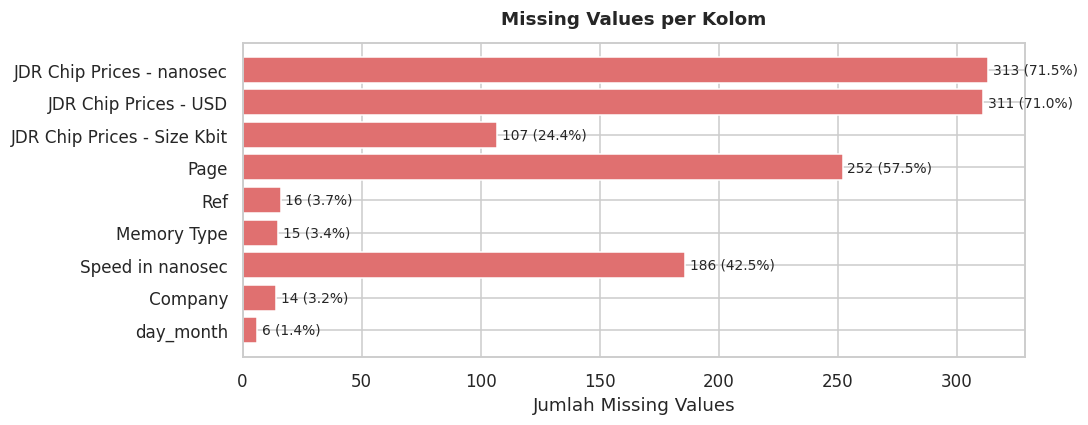

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing[missing > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing.values, color='#e07070', edgecolor='white')
for bar, val in zip(bars, cols_with_missing.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Jumlah Missing Values')
ax.set_title('Missing Values per Kolom', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Berdasarkan hasil perhitungan jumlah dan persentase nilai hilang (*missing values*), terlihat bahwa beberapa variabel dalam dataset memiliki tingkat ketidaklengkapan yang signifikan. Kolom dengan tingkat missing tertinggi adalah *JDR Chip Prices - nanosec* (71.46%) dan *JDR Chip Prices - USD* (71.00%), diikuti oleh *Page* (57.53%) dan *Speed in nanosec* (42.47%). Tingginya persentase nilai hilang pada kolom-kolom tersebut menunjukkan bahwa data tidak tersedia secara konsisten dan berpotensi mengganggu analisis jika tetap dipertahankan tanpa penanganan khusus.

Sementara itu, kolom seperti *JDR Chip Prices - Size Kbit* memiliki missing sebesar 24.43%, yang masih tergolong cukup tinggi namun dapat dipertimbangkan untuk imputasi tergantung kebutuhan analisis. Di sisi lain, variabel utama seperti *Company* (3.20%), *Memory Type* (3.42%), dan *day_month* (1.30%) memiliki tingkat missing yang relatif rendah sehingga lebih aman untuk dilakukan imputasi sederhana, seperti pengisian dengan nilai kategorikal “Unknown”.

Secara keseluruhan, strategi penanganan missing values perlu disesuaikan dengan tingkat kehilangan data, di mana kolom dengan missing tinggi cenderung dihapus atau diabaikan, sedangkan kolom dengan missing rendah dapat diperbaiki melalui teknik imputasi. Pendekatan ini bertujuan untuk menjaga kualitas dataset tanpa mengorbankan terlalu banyak informasi penting.

##### b. Pembersihan missing value dan penambahan kolom

 Data Cleaning dan Transformasi Dataset Harga Memori

Kode berikut bertujuan untuk melakukan proses *data cleaning* dan transformasi pada dataset harga memori agar siap digunakan dalam analisis lebih lanjut. Tahap awal dilakukan dengan menyeleksi variabel-variabel yang relevan, yaitu tahun (*year*), perusahaan (*Company*), kapasitas (*Size in Kbyte*), biaya (*Cost in USD*), kecepatan (*Speed in nanosec*), dan tipe memori (*Memory Type*), sehingga hanya atribut penting yang dipertahankan.

Selanjutnya, dilakukan penanganan nilai hilang (*missing values*) dengan menggantinya menjadi "Unknown" pada kolom *Company* dan *Memory Type* guna menjaga konsistensi data serta menghindari error dalam proses analisis. Setelah itu, dataset difilter untuk menghapus entri yang tidak valid, khususnya data dengan nilai biaya atau kapasitas kurang dari atau sama dengan nol, sehingga hanya observasi yang logis dan dapat dipertanggungjawabkan yang digunakan.

Tahap berikutnya adalah pembuatan variabel turunan, yaitu *Cost per KB* dan *Cost per MB*, yang memungkinkan analisis efisiensi harga berdasarkan kapasitas. Selain itu, dilakukan konversi kapasitas dari kilobyte ke megabyte untuk standarisasi satuan pengukuran. Terakhir, variabel *Decade* dibentuk dengan mengelompokkan tahun ke dalam dekade tertentu, sehingga memudahkan analisis tren jangka panjang.

Melalui proses ini, dihasilkan dataset yang lebih bersih, terstruktur, dan siap digunakan untuk analisis statistik maupun visualisasi data.

In [ ]:
df_clean = df[['year', 'Company', 'Size in Kbyte', 'Cost in USD', 'Speed in nanosec', 'Memory Type']].copy()
df_clean['Company'] = df_clean['Company'].fillna('Unknown')
df_clean['Memory Type'] = df_clean['Memory Type'].fillna('Unknown')
df_clean = df_clean[(df_clean['Cost in USD'] > 0) & (df_clean['Size in Kbyte'] > 0)]
df_clean['Cost_per_KB']   = df_clean['Cost in USD'] / df_clean['Size in Kbyte']
df_clean['Size_in_MB']    = df_clean['Size in Kbyte'] / 1024
df_clean['Cost_per_MB']   = df_clean['Cost in USD'] / df_clean['Size_in_MB'].replace(0, np.nan)
df_clean['Decade']        = (df_clean['year'] // 10 * 10).astype(str) + 's'
print(f"Data bersih: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
df_clean.head()

Data bersih: 438 baris, 10 kolom


,year,Company,Size in Kbyte,Cost in USD,Speed in nanosec,Memory Type,Cost_per_KB,Size_in_MB,Cost_per_MB,Decade
0,1957,C.C.C.,0.000977,392.00,10000,Flip-Flop transistor,401407.794479,9.536748e-07,4.110416e+08,1950s
1,1959,E.E.Co.,0.000977,64.80,10000,Flip-Flop - vacuum tube,66355.166026,9.536748e-07,6.794769e+07,1950s
2,1960,IBM,0.000977,5.00,11500,Core memory for IBM 1401,5119.997379,9.536748e-07,5.242877e+06,1960s
3,1965,IBM,0.000977,2.52,2000,Core Memory for IBM 360/30,2580.478679,9.536748e-07,2.642410e+06,1960s
4,1970,IBM,0.000977,0.70,770,Core Memory for IBM 370/135,716.799633,9.536748e-07,7.340028e+05,1970s


c.Pembersihan duplicated data

In [ ]:
dupes = df_clean.duplicated().sum()
print(f" Jumlah baris duplikat: {dupes}")
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"   → Duplikat dihapus. Sisa baris: {len(df_clean)}")
else:
    print("   → Tidak ada duplikat.")

 Jumlah baris duplikat: 69
   → Duplikat dihapus. Sisa baris: 369


Pada tahap ini dilakukan pemeriksaan terhadap keberadaan data duplikat dalam dataset yang telah dibersihkan (*df_clean*). Proses ini bertujuan untuk memastikan bahwa setiap baris data merepresentasikan observasi yang unik sehingga tidak terjadi bias dalam analisis.

Fungsi `duplicated().sum()` digunakan untuk menghitung jumlah baris yang teridentifikasi sebagai duplikat. Jika ditemukan data duplikat, maka dilakukan penghapusan menggunakan metode `drop_duplicates()` untuk menjaga integritas dan keakuratan dataset. Sebaliknya, jika tidak ditemukan duplikasi, maka dataset dianggap telah bersih dari redundansi data.

Langkah ini penting dalam proses *data preprocessing* karena keberadaan duplikat dapat memengaruhi hasil analisis statistik, seperti perhitungan rata-rata, distribusi data, maupun visualisasi, yang pada akhirnya dapat menghasilkan interpretasi yang tidak valid.


##  4. Statistik Deskriptif

In [ ]:
num_cols = ['Cost in USD', 'Size in Kbyte', 'Cost_per_KB', 'Cost_per_MB']
df_clean[num_cols].describe().T.style.background_gradient(cmap='Blues').format('{:.4f}')

,count,mean,std,min,25%,50%,75%,max
Cost in USD,369.0000,196.5773,339.1393,0.3000,53.9900,91.9900,175.0000,4680.0000
Size in Kbyte,369.0000,10357708.2636,16475337.5078,0.0010,8192.0000,1048576.0000,16777216.0000,67108864.0000
Cost_per_KB,369.0000,1295.2523,21171.2744,0.0000,0.0000,0.0001,0.0312,401407.7945
Cost_per_MB,369.0000,1326338.3146,21679385.0313,0.0013,0.0055,0.1260,32.0000,411041581.5467



Berdasarkan hasil analisis statistik deskriptif terhadap variabel numerik, terlihat bahwa dataset memiliki variasi nilai yang cukup tinggi, terutama pada variabel biaya dan kapasitas memori. Variabel *Cost in USD* memiliki rata-rata sebesar 196.58 dengan nilai maksimum mencapai 4680, yang menunjukkan adanya *outlier* atau lonjakan harga ekstrem dalam dataset. Hal ini juga diperkuat oleh nilai standar deviasi yang relatif besar (339.14), menandakan distribusi data yang menyebar luas.

Pada variabel *Size in Kbyte*, rata-rata kapasitas memori mencapai lebih dari 10 juta Kbyte (sekitar 10 GB), dengan nilai maksimum hingga 67 juta Kbyte (64 GB), yang mencerminkan perkembangan teknologi memori dari waktu ke waktu. Standar deviasi yang tinggi juga menunjukkan adanya variasi besar antara generasi awal dan modern.

Variabel turunan *Cost_per_KB* dan *Cost_per_MB* menunjukkan distribusi yang sangat tidak merata, dengan perbedaan ekstrem antara nilai minimum dan maksimum. Nilai maksimum yang sangat tinggi mengindikasikan adanya data historis lama dengan biaya per unit yang sangat mahal dibandingkan teknologi modern, sehingga distribusi cenderung *skewed* (miring ke kanan).

Secara keseluruhan, statistik deskriptif ini mengindikasikan bahwa dataset memiliki distribusi yang tidak normal, banyak dipengaruhi oleh *outlier*, serta mencerminkan perubahan signifikan dalam harga dan kapasitas memori sepanjang waktu. Oleh karena itu, analisis lanjutan sebaiknya mempertimbangkan transformasi data atau penggunaan metode robust untuk menghindari bias akibat nilai ekstrem.


## 5. Visualisasi Data

#### a. Distribusi Harga Memori (Histogram + KDE)

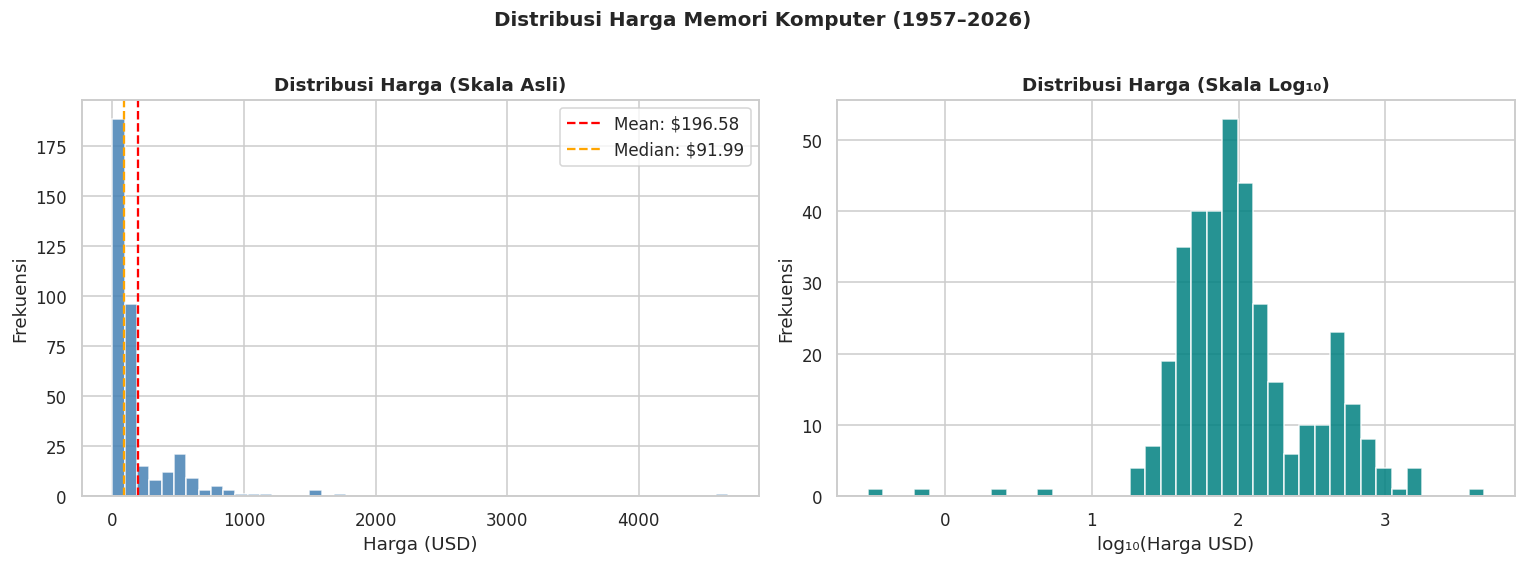

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Cost in USD'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Harga (Skala Asli)', fontweight='bold')
axes[0].set_xlabel('Harga (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_clean['Cost in USD'].mean(),   color='red',    linestyle='--', label=f"Mean: ${df_clean['Cost in USD'].mean():.2f}")
axes[0].axvline(df_clean['Cost in USD'].median(), color='orange', linestyle='--', label=f"Median: ${df_clean['Cost in USD'].median():.2f}")
axes[0].legend()

log_cost = np.log10(df_clean['Cost in USD'].replace(0, np.nan).dropna())
axes[1].hist(log_cost, bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Harga (Skala Log₁₀)', fontweight='bold')
axes[1].set_xlabel('log₁₀(Harga USD)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Harga Memori Komputer (1957–2026)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Visualisasi distribusi harga memori menunjukkan bahwa data memiliki distribusi yang sangat tidak simetris (*positively skewed*). Pada histogram dengan skala asli, sebagian besar data terkonsentrasi pada rentang harga rendah, sementara terdapat sejumlah kecil nilai ekstrem yang berada jauh di sisi kanan distribusi. Hal ini menyebabkan nilai rata-rata (mean = 196.58 USD) lebih tinggi dibandingkan median (91.99 USD), yang mengindikasikan adanya pengaruh kuat dari *outlier*.

Distribusi yang miring ini mencerminkan kondisi historis harga memori, di mana pada periode awal teknologi, harga per unit sangat tinggi, kemudian mengalami penurunan drastis seiring perkembangan teknologi, sebelum kembali meningkat pada periode tertentu. Oleh karena itu, distribusi tidak mengikuti pola normal.

Untuk mengatasi ketidakseimbangan tersebut, dilakukan transformasi logaritmik (log₁₀) pada variabel harga. Hasilnya menunjukkan distribusi yang lebih mendekati normal, dengan penyebaran data yang lebih merata dan pola yang lebih mudah dianalisis. Transformasi ini membantu mengurangi efek *skewness* serta mempermudah interpretasi hubungan antar variabel dalam analisis lanjutan.

Dengan demikian, penggunaan skala logaritmik menjadi pendekatan yang lebih representatif dalam menganalisis distribusi harga memori yang memiliki rentang nilai sangat luas dan dipengaruhi oleh perubahan teknologi jangka panjang.

#### b. Tren Harga Per KB Sepanjang Tahun (Line Chart)

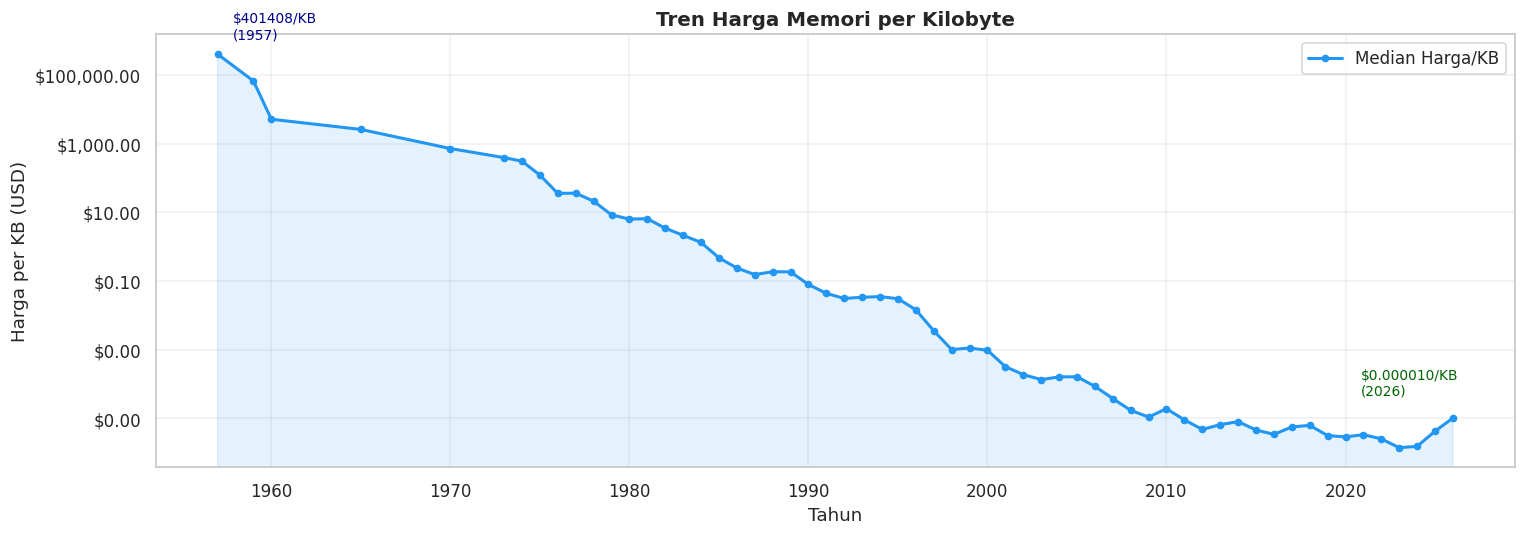

In [ ]:
yearly = df_clean.groupby('year').agg(
    avg_cost_per_kb = ('Cost_per_KB', 'median'),
    avg_cost        = ('Cost in USD', 'median'),
    count           = ('Cost in USD', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(yearly['year'], yearly['avg_cost_per_kb'],
            marker='o', markersize=4, linewidth=2, color='#2196F3', label='Median Harga/KB')
ax.fill_between(yearly['year'], yearly['avg_cost_per_kb'], alpha=0.12, color='#2196F3')

ax.set_title('Tren Harga Memori per Kilobyte', fontweight='bold', fontsize=13)
ax.set_xlabel('Tahun')
ax.set_ylabel('Harga per KB (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.2f}'))
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax.annotate(f"${yearly['avg_cost_per_kb'].iloc[0]:.0f}/KB\n({yearly['year'].iloc[0]})",
            xy=(yearly['year'].iloc[0], yearly['avg_cost_per_kb'].iloc[0]),
            xytext=(10, 10), textcoords='offset points', fontsize=9, color='darkblue')
ax.annotate(f"${yearly['avg_cost_per_kb'].iloc[-1]:.6f}/KB\n({yearly['year'].iloc[-1]})",
            xy=(yearly['year'].iloc[-1], yearly['avg_cost_per_kb'].iloc[-1]),
            xytext=(-60, 15), textcoords='offset points', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()


Visualisasi tren harga memori per kilobyte menunjukkan penurunan yang sangat signifikan sepanjang periode 1957 hingga 2026. Dengan menggunakan skala logaritmik, terlihat bahwa harga memori mengalami penurunan eksponensial, terutama pada dekade awal perkembangan teknologi komputer. Pada tahun 1957, harga memori tercatat sangat tinggi, mencapai sekitar $401,408 per kilobyte, yang mencerminkan keterbatasan teknologi pada masa tersebut.

Seiring dengan kemajuan teknologi, khususnya dalam bidang semikonduktor dan produksi massal, harga memori mengalami penurunan yang konsisten selama beberapa dekade. Tren ini sejalan dengan prinsip Moore’s Law, di mana peningkatan kapasitas dan efisiensi produksi menyebabkan biaya per unit terus menurun.

Namun demikian, pada periode mendekati tahun 2026, terlihat adanya perlambatan penurunan harga bahkan kecenderungan stabilisasi. Hal ini mengindikasikan adanya perubahan struktur pasar, seperti meningkatnya permintaan terhadap memori untuk kebutuhan komputasi modern (misalnya kecerdasan buatan), yang dapat memengaruhi dinamika harga.

Secara keseluruhan, grafik ini menunjukkan bahwa harga memori per kilobyte tidak hanya dipengaruhi oleh perkembangan teknologi, tetapi juga oleh faktor ekonomi dan permintaan pasar global, sehingga membentuk pola jangka panjang yang kompleks namun dapat diamati secara sistematis melalui skala logaritmik.

#### c. Jumlah Data per Dekade (Bar Chart)

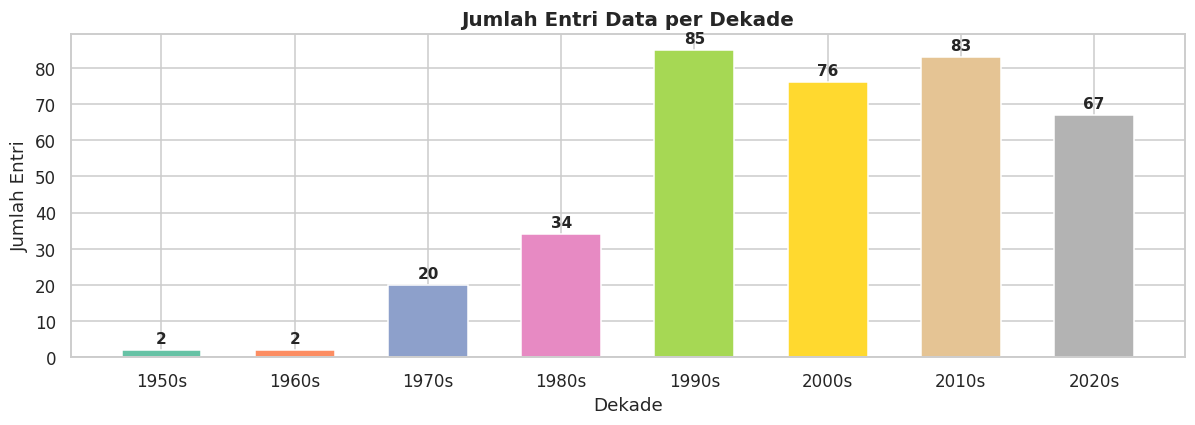

In [ ]:
decade_count = df_clean['Decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
colors = sns.color_palette('Set2', len(decade_count))
bars = ax.bar(decade_count.index, decade_count.values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, decade_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Jumlah Entri Data per Dekade', fontweight='bold', fontsize=13)
ax.set_xlabel('Dekade')
ax.set_ylabel('Jumlah Entri')
plt.tight_layout()
plt.show()

Visualisasi jumlah entri data per dekade menunjukkan distribusi data yang tidak merata sepanjang periode pengamatan. Pada dekade awal, yaitu 1950-an dan 1960-an, jumlah data sangat terbatas dengan masing-masing hanya 2 entri, yang mencerminkan keterbatasan dokumentasi dan perkembangan teknologi pada masa tersebut.

Jumlah data mulai meningkat pada dekade 1970-an (20 entri) dan 1980-an (34 entri), seiring dengan berkembangnya industri komputer dan meningkatnya produksi serta dokumentasi teknologi memori. Puncak jumlah data terjadi pada dekade 1990-an (85 entri), diikuti oleh 2010-an (83 entri) dan 2000-an (76 entri), yang menunjukkan periode dengan aktivitas teknologi dan ketersediaan data yang tinggi.

Pada dekade 2020-an, jumlah data sedikit menurun menjadi 67 entri, yang kemungkinan disebabkan oleh keterbatasan data terbaru atau belum lengkapnya pencatatan hingga akhir dekade.

Secara keseluruhan, distribusi ini menunjukkan bahwa dataset lebih representatif untuk periode modern dibandingkan periode awal, sehingga analisis historis perlu mempertimbangkan potensi bias akibat ketidakseimbangan jumlah data antar dekade.

#### d. Top 10 Perusahaan Berdasarkan Jumlah Produk

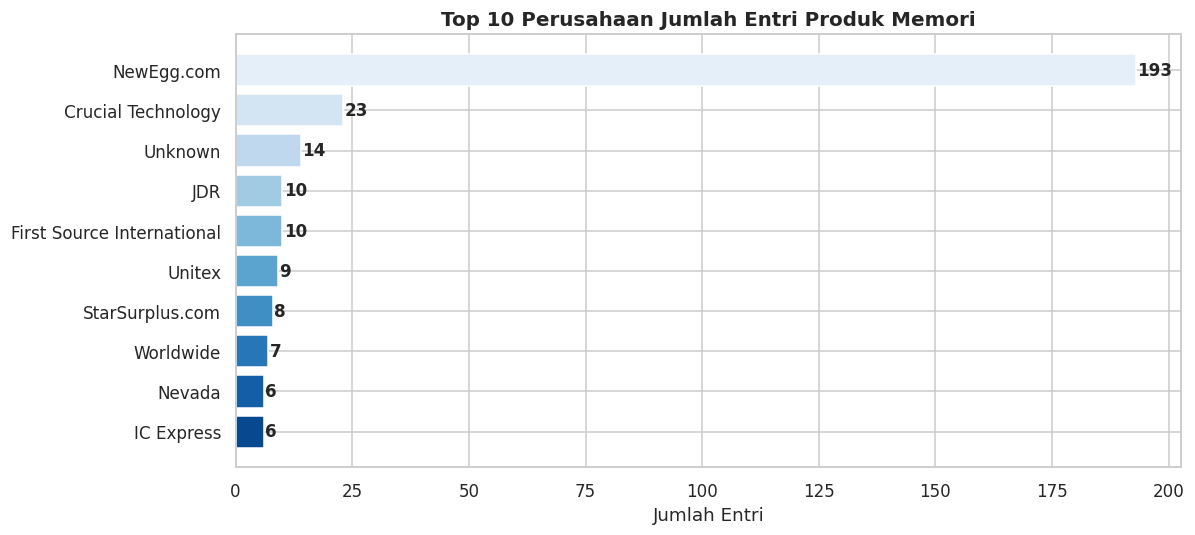

In [ ]:
top_companies = df_clean['Company'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('Blues_r', 10)
bars = ax.barh(top_companies.index[::-1], top_companies.values[::-1], color=palette, edgecolor='white')
for bar, val in zip(bars, top_companies.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Top 10 Perusahaan Jumlah Entri Produk Memori', fontweight='bold', fontsize=13)
ax.set_xlabel('Jumlah Entri')
plt.tight_layout()
plt.show()


Visualisasi menunjukkan distribusi jumlah entri produk memori berdasarkan perusahaan atau sumber data. Terlihat bahwa *NewEgg.com* mendominasi dataset dengan jumlah entri yang sangat signifikan, yaitu sebanyak 193 entri, jauh melampaui entitas lainnya. Hal ini mengindikasikan bahwa sebagian besar data berasal dari satu sumber utama, sehingga terdapat potensi bias dalam representasi dataset.

Perusahaan lain seperti *Crucial Technology* memiliki kontribusi yang jauh lebih kecil (23 entri), diikuti oleh kategori *Unknown* (14 entri), serta beberapa entitas lain seperti *JDR* dan *First Source International* dengan jumlah yang relatif terbatas. Distribusi ini menunjukkan bahwa dataset tidak seimbang dalam hal sumber data, di mana sebagian besar observasi terkonsentrasi pada satu platform.

Ketimpangan ini dapat memengaruhi hasil analisis, terutama jika karakteristik produk atau harga dari sumber dominan berbeda dengan sumber lainnya. Oleh karena itu, perlu kehati-hatian dalam menarik kesimpulan umum, serta pertimbangan untuk melakukan normalisasi atau analisis terpisah berdasarkan sumber data guna mengurangi bias.

#### e. Distribusi Harga per Dekade (Box Plot)

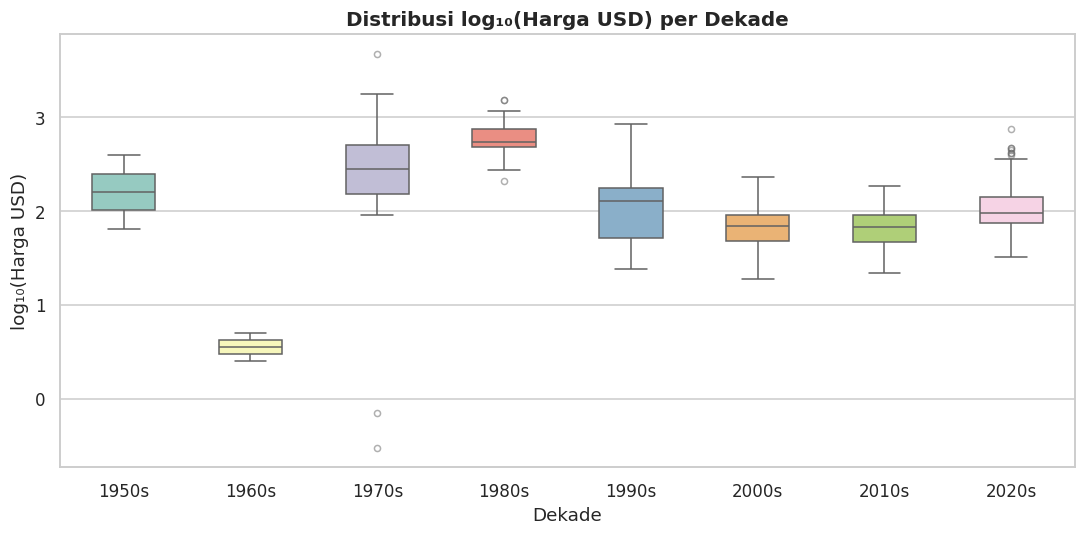

In [ ]:
df_plot = df_clean[df_clean['Cost in USD'] > 0].copy()
df_plot['log_cost'] = np.log10(df_plot['Cost in USD'])

decade_order = sorted(df_plot['Decade'].unique())

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot, x='Decade', y='log_cost', order=decade_order,
            palette='Set3', ax=ax, width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5))

ax.set_title('Distribusi log₁₀(Harga USD) per Dekade', fontweight='bold', fontsize=13)
ax.set_xlabel('Dekade')
ax.set_ylabel('log₁₀(Harga USD)')
plt.tight_layout()
plt.show()


Boxplot distribusi log₁₀(harga) per dekade menunjukkan dinamika harga memori yang berubah secara signifikan sepanjang waktu. Pada dekade awal seperti 1950-an dan 1960-an, harga relatif tinggi dengan variasi yang terbatas, meskipun jumlah data yang sedikit membuat interpretasi kurang representatif.

Memasuki dekade 1970-an dan 1980-an, terlihat peningkatan variasi harga yang cukup signifikan, ditandai dengan rentang interkuartil yang lebih lebar serta munculnya beberapa *outlier*. Hal ini mencerminkan fase transisi teknologi di mana berbagai jenis memori dengan karakteristik berbeda mulai berkembang.

Pada dekade 1990-an hingga 2010-an, distribusi harga cenderung menurun dan menjadi lebih stabil, yang menunjukkan adanya efisiensi produksi dan standarisasi teknologi. Rentang distribusi yang lebih sempit mengindikasikan bahwa harga menjadi lebih seragam di pasar.

Namun, pada dekade 2020-an, terlihat adanya sedikit peningkatan median harga serta variasi yang kembali melebar. Hal ini dapat dikaitkan dengan perubahan dinamika pasar, seperti meningkatnya permintaan terhadap teknologi komputasi modern yang berdampak pada harga memori.

Secara keseluruhan, boxplot ini menunjukkan bahwa distribusi harga tidak hanya mengalami penurunan jangka panjang, tetapi juga fluktuasi antar dekade yang dipengaruhi oleh perkembangan teknologi dan kondisi pasar.

#### f. Scatter Plot Ukuran vs Harga

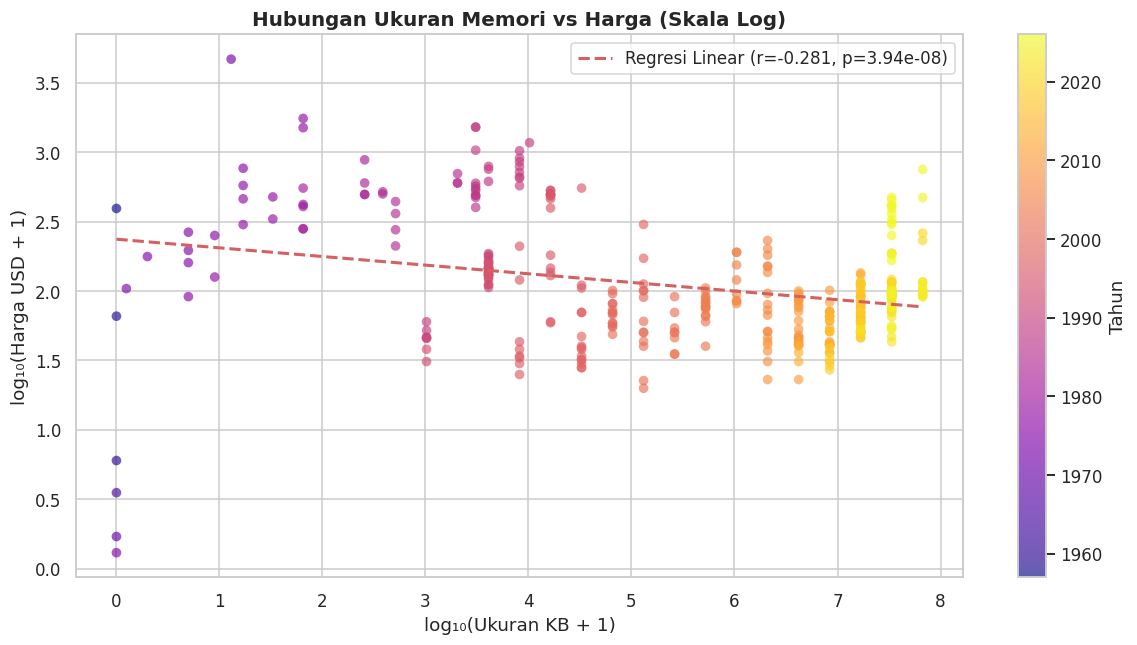


 Korelasi Pearson (log-log): r = -0.2812
   Ini menunjukkan korelasi lemah/negatif antara ukuran dan harga.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(
    np.log10(df_clean['Size in Kbyte'] + 1),
    np.log10(df_clean['Cost in USD'] + 1),
    c=df_clean['year'], cmap='plasma', alpha=0.65, s=40, edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Tahun')

x = np.log10(df_clean['Size in Kbyte'] + 1)
y = np.log10(df_clean['Cost in USD'] + 1)
mask = np.isfinite(x) & np.isfinite(y)
slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, slope * xline + intercept, 'r--', linewidth=2,
        label=f'Regresi Linear (r={r:.3f}, p={p:.2e})')

ax.set_title('Hubungan Ukuran Memori vs Harga (Skala Log)', fontweight='bold', fontsize=13)
ax.set_xlabel('log₁₀(Ukuran KB + 1)')
ax.set_ylabel('log₁₀(Harga USD + 1)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n Korelasi Pearson (log-log): r = {r:.4f}")
print(f"   Ini menunjukkan {'korelasi POSITIF kuat' if r > 0.5 else 'korelasi lemah/negatif'} antara ukuran dan harga.")

Visualisasi scatter plot menunjukkan hubungan antara ukuran memori dan harga dalam skala logaritmik. Secara umum, terlihat adanya kecenderungan hubungan negatif antara ukuran memori (dalam KB) dan harga, yang ditunjukkan oleh garis regresi linear dengan koefisien korelasi sebesar r = -0.281 dan nilai signifikansi p < 0.001.

Nilai korelasi negatif ini mengindikasikan bahwa semakin besar kapasitas memori, maka harga relatif per unit cenderung lebih rendah. Fenomena ini sejalan dengan prinsip ekonomi skala (*economies of scale*) dan perkembangan teknologi, di mana peningkatan kapasitas produksi dan efisiensi manufaktur menurunkan biaya per unit memori.

Namun demikian, kekuatan korelasi yang relatif lemah (|r| < 0.3) menunjukkan bahwa hubungan ini tidak sepenuhnya linear dan dipengaruhi oleh faktor lain, seperti periode waktu, jenis teknologi memori, serta kondisi pasar. Hal ini juga diperkuat oleh penyebaran data yang cukup luas pada setiap rentang ukuran.

Selain itu, pewarnaan berdasarkan tahun menunjukkan adanya pola temporal, di mana data dari periode lebih baru cenderung berada pada area dengan ukuran lebih besar dan harga relatif lebih rendah, mencerminkan kemajuan teknologi dari waktu ke waktu.

Secara keseluruhan, meskipun terdapat hubungan negatif antara ukuran dan harga, faktor waktu dan evolusi teknologi memiliki peran yang lebih dominan dalam menentukan harga memori.

#### g. Heatmap Korelasi Antar Variabel Numerik

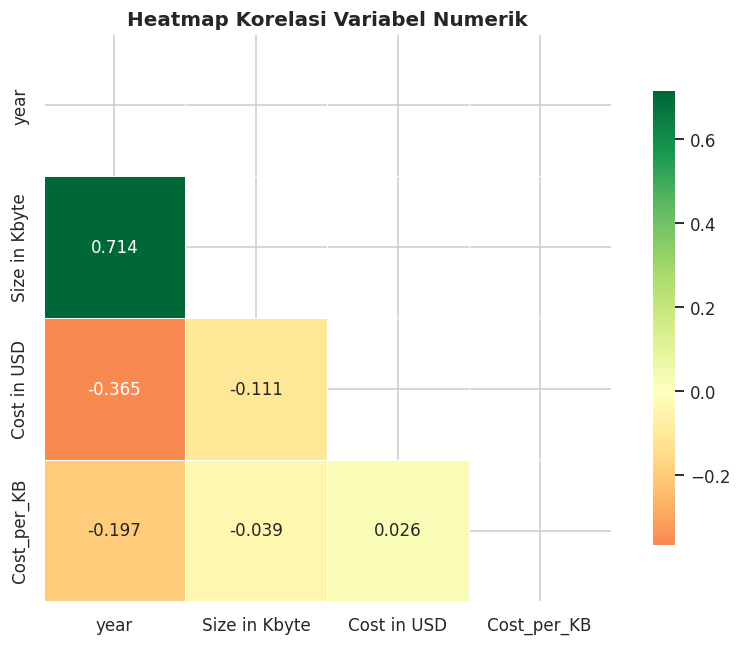

In [ ]:
corr_cols = ['year', 'Size in Kbyte', 'Cost in USD', 'Cost_per_KB']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Heatmap Korelasi Variabel Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


Heatmap korelasi menunjukkan hubungan antar variabel numerik dalam dataset, yaitu *year*, *Size in Kbyte*, *Cost in USD*, dan *Cost_per_KB*. Nilai korelasi berkisar antara -1 hingga 1, di mana nilai positif menunjukkan hubungan searah dan nilai negatif menunjukkan hubungan berlawanan.

Hasil analisis menunjukkan bahwa variabel *year* memiliki korelasi positif yang kuat dengan *Size in Kbyte* (r = 0.714), yang mengindikasikan bahwa kapasitas memori meningkat secara signifikan seiring waktu. Hal ini sejalan dengan perkembangan teknologi yang memungkinkan peningkatan kapasitas secara eksponensial.

Sebaliknya, *year* memiliki korelasi negatif dengan *Cost in USD* (r = -0.365) dan *Cost_per_KB* (r = -0.197), yang menunjukkan bahwa harga memori cenderung menurun seiring waktu, meskipun tidak secara linear sempurna.

Korelasi antara *Size in Kbyte* dan *Cost in USD* relatif lemah (r = -0.111), yang mengindikasikan bahwa ukuran memori bukan faktor utama yang menentukan harga absolut. Sementara itu, hubungan antara *Cost in USD* dan *Cost_per_KB* hampir tidak signifikan (r = 0.026), menunjukkan bahwa harga total tidak secara langsung mencerminkan efisiensi harga per unit.

Secara keseluruhan, hasil ini menegaskan bahwa variabel waktu (*year*) merupakan faktor paling dominan dalam memengaruhi perubahan kapasitas dan harga memori, dibandingkan variabel lainnya.

#### h. Deteksi Outlier dengan Z-Score

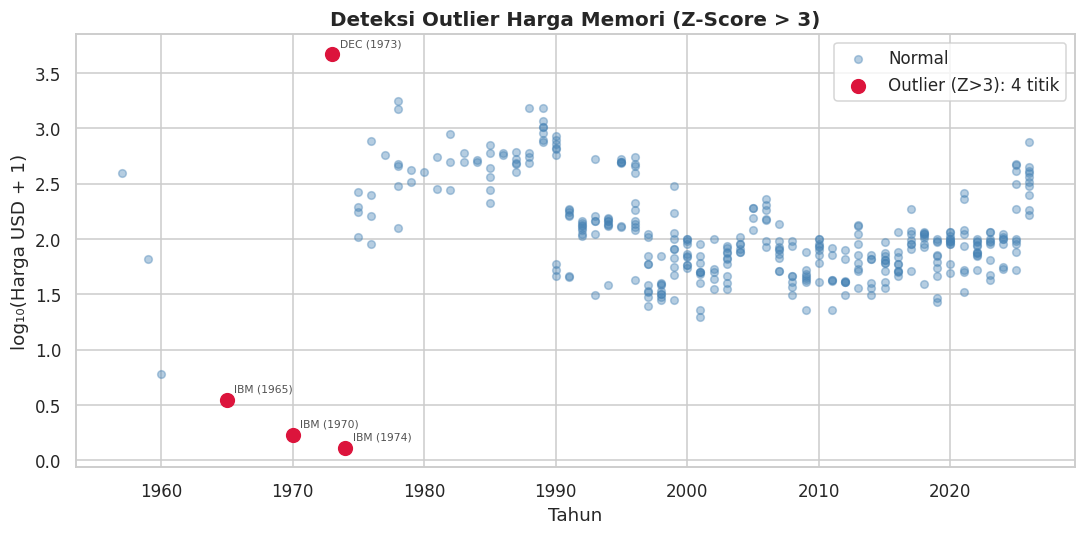


Jumlah outlier terdeteksi: 4
   year  Cost in USD Company
5  1973      4680.00     DEC
3  1965         2.52     IBM
4  1970         0.70     IBM
6  1974         0.30     IBM


In [ ]:
df_out = df_clean[['year', 'Cost in USD', 'Size in Kbyte', 'Company']].dropna().copy()
df_out['z_cost'] = np.abs(stats.zscore(np.log10(df_out['Cost in USD'] + 1)))
outliers = df_out[df_out['z_cost'] > 3]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_out['year'], np.log10(df_out['Cost in USD'] + 1),
           alpha=0.4, color='steelblue', s=25, label='Normal')
ax.scatter(outliers['year'], np.log10(outliers['Cost in USD'] + 1),
           color='crimson', s=80, zorder=5, label=f'Outlier (Z>3): {len(outliers)} titik')

for _, row in outliers.iterrows():
    ax.annotate(f"{row['Company']} ({row['year']})",
                xy=(row['year'], np.log10(row['Cost in USD'] + 1)),
                fontsize=7, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Deteksi Outlier Harga Memori (Z-Score > 3)', fontweight='bold', fontsize=13)
ax.set_xlabel('Tahun')
ax.set_ylabel('log₁₀(Harga USD + 1)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nJumlah outlier terdeteksi: {len(outliers)}")
print(outliers[['year', 'Cost in USD', 'Company']].sort_values('Cost in USD', ascending=False).head(10))

Deteksi outlier dilakukan menggunakan metode Z-score dengan ambang batas |Z| > 3 untuk mengidentifikasi nilai yang secara statistik jauh dari distribusi normal. Hasil visualisasi menunjukkan terdapat beberapa titik data yang dikategorikan sebagai outlier, yang ditandai dengan warna merah.

Outlier tersebut sebagian besar berasal dari periode awal perkembangan teknologi (1960-an hingga 1970-an), di mana harga memori menunjukkan nilai yang sangat ekstrem dibandingkan distribusi umum. Hal ini dapat disebabkan oleh keterbatasan teknologi, variasi spesifikasi produk, serta kondisi pasar yang belum stabil pada masa tersebut.

Sebagian outlier menunjukkan harga yang sangat rendah, sementara yang lain menunjukkan harga yang sangat tinggi, yang mengindikasikan adanya variasi besar dalam produk memori pada periode tersebut. Meskipun secara statistik dianggap sebagai outlier, nilai-nilai ini tetap memiliki makna historis yang penting dan tidak selalu perlu dihapus.

Oleh karena itu, keputusan untuk menghapus atau mempertahankan outlier harus disesuaikan dengan tujuan analisis. Dalam konteks analisis historis, outlier justru dapat memberikan wawasan penting mengenai evolusi teknologi dan dinamika harga pada masa awal perkembangan industri memori.

#### i. Penurunan Harga per KB  Rata-Rata per Tahun

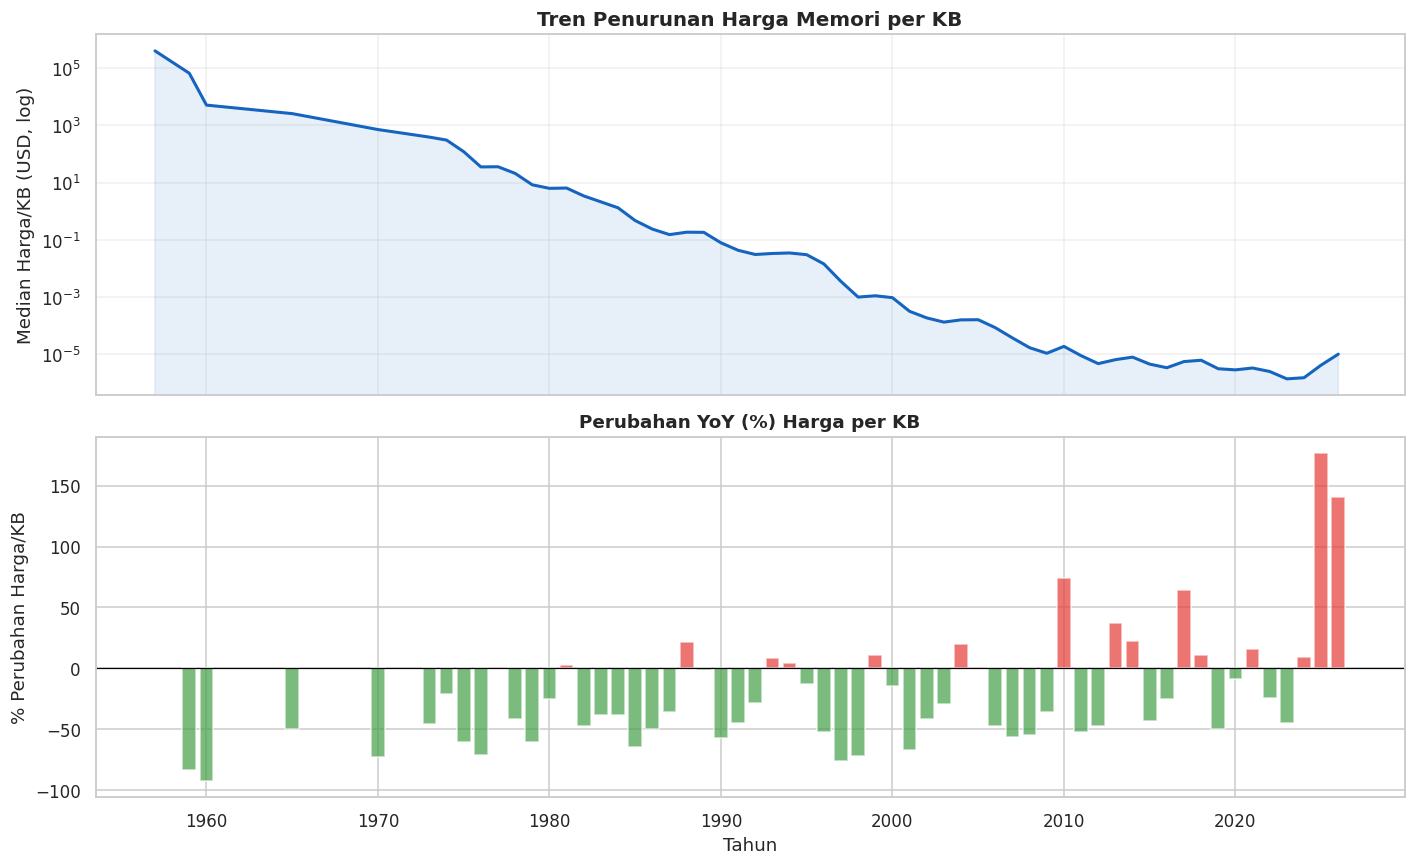

In [ ]:
annual = df_clean.groupby('year')['Cost_per_KB'].median().reset_index()
annual['pct_change'] = annual['Cost_per_KB'].pct_change() * 100
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].semilogy(annual['year'], annual['Cost_per_KB'], color='#1565C0', linewidth=2)
axes[0].fill_between(annual['year'], annual['Cost_per_KB'], alpha=0.1, color='#1565C0')
axes[0].set_ylabel('Median Harga/KB (USD, log)')
axes[0].set_title('Tren Penurunan Harga Memori per KB', fontweight='bold', fontsize=13)
axes[0].grid(True, which='both', alpha=0.3)
pct = annual['pct_change'].dropna()
years_pct = annual['year'].iloc[1:]
colors_bar = ['#e53935' if v > 0 else '#43a047' for v in pct]
axes[1].bar(years_pct, pct, color=colors_bar, width=0.8, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('% Perubahan Harga/KB')
axes[1].set_xlabel('Tahun')
axes[1].set_title('Perubahan YoY (%) Harga per KB', fontweight='bold')

plt.tight_layout()
plt.show()



Visualisasi tren median harga memori per kilobyte menunjukkan pola penurunan eksponensial yang sangat signifikan dari tahun 1957 hingga sekitar awal 2000-an. Dengan menggunakan skala logaritmik, terlihat bahwa harga memori mengalami penurunan tajam pada dekade-dekade awal, mencerminkan kemajuan teknologi semikonduktor dan peningkatan efisiensi produksi.

Setelah memasuki periode modern, terutama setelah tahun 2000, laju penurunan harga mulai melambat dan cenderung mengalami stabilisasi. Hal ini menunjukkan bahwa teknologi memori telah mencapai tingkat kematangan tertentu, di mana efisiensi tambahan menjadi lebih sulit dicapai.

Grafik perubahan *year-over-year* (YoY) memperkuat temuan tersebut, di mana sebagian besar periode historis menunjukkan penurunan harga (nilai negatif), terutama pada dekade 1960-an hingga 1990-an. Namun, pada beberapa periode tertentu, khususnya di tahun-tahun terbaru, terlihat adanya lonjakan positif (kenaikan harga), yang mengindikasikan gangguan pasar atau peningkatan permintaan.

Fenomena kenaikan harga pada periode modern dapat dikaitkan dengan faktor eksternal seperti meningkatnya kebutuhan komputasi (misalnya kecerdasan buatan), keterbatasan kapasitas produksi, serta dinamika rantai pasok global.

Secara keseluruhan, meskipun tren jangka panjang menunjukkan penurunan harga memori, data terbaru mengindikasikan adanya perubahan pola menuju stabilisasi bahkan potensi kenaikan harga dalam jangka pendek.

#### j. Distribusi Ukuran Memori per Dekade (Violin Plot)

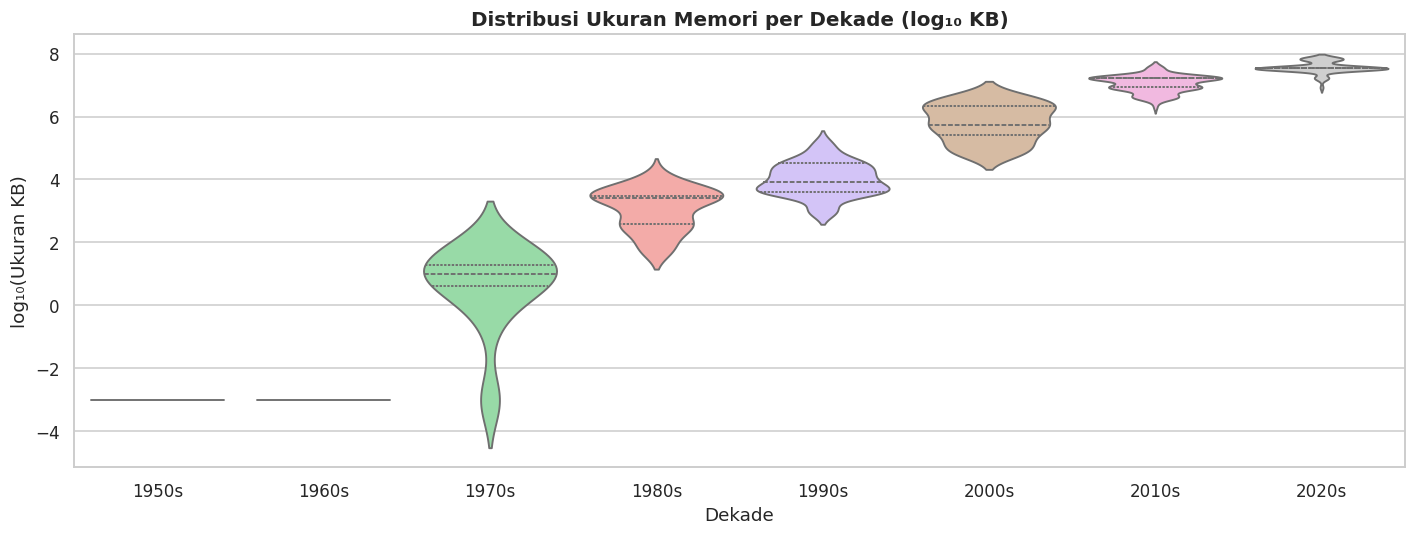

In [ ]:
df_vio = df_clean[df_clean['Size in Kbyte'] > 0].copy()
df_vio['log_size'] = np.log10(df_vio['Size in Kbyte'])

decade_order_vio = sorted(df_vio['Decade'].unique())

fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=df_vio, x='Decade', y='log_size',
               order=decade_order_vio, palette='pastel',
               inner='quartile', ax=ax)
ax.set_title('Distribusi Ukuran Memori per Dekade (log₁₀ KB)', fontweight='bold', fontsize=13)
ax.set_xlabel('Dekade')
ax.set_ylabel('log₁₀(Ukuran KB)')
plt.tight_layout()
plt.show()

## Analisis Distribusi Ukuran Memori per Dekade (Skala Log₁₀)

Visualisasi violin plot menunjukkan distribusi ukuran memori (dalam skala log₁₀ KB) untuk setiap dekade. Secara umum, terlihat adanya pergeseran distribusi ke arah nilai yang lebih tinggi seiring berjalannya waktu, yang mengindikasikan peningkatan kapasitas memori secara signifikan dari dekade ke dekade.

Pada dekade awal (1950-an dan 1960-an), ukuran memori berada pada nilai yang sangat kecil dengan variasi yang terbatas, mencerminkan keterbatasan teknologi pada masa tersebut. Memasuki dekade 1970-an hingga 1990-an, distribusi mulai melebar, menunjukkan adanya diversifikasi teknologi dan peningkatan kapasitas yang lebih cepat.

Pada dekade 2000-an hingga 2020-an, distribusi ukuran memori bergeser secara konsisten ke nilai yang lebih tinggi dengan variasi yang relatif lebih stabil. Hal ini menunjukkan bahwa teknologi memori telah mencapai tahap kematangan, dengan kapasitas besar menjadi standar dan variasi yang lebih terkendali.

Selain itu, bentuk distribusi yang semakin rapat pada dekade modern menunjukkan adanya standarisasi dalam kapasitas memori yang diproduksi secara massal.

Secara keseluruhan, grafik ini mengonfirmasi bahwa kapasitas memori mengalami pertumbuhan eksponensial sepanjang waktu, sejalan dengan perkembangan teknologi komputasi modern.


##  6. Identifikasi Pola & Insight Menarik

In [ ]:
print("═" * 60)
print(" INSIGHT 1: Penurunan Harga Memory 1957–2026")
print("═" * 60)
harga_1957 = df_clean[df_clean['year'] == df_clean['year'].min()]['Cost_per_KB'].median()
harga_2020s = df_clean[df_clean['year'] >= 2020]['Cost_per_KB'].median()
print(f"  Harga/KB di {df_clean['year'].min()} : ${harga_1957:,.2f}")
print(f"  Harga/KB di 2020+       : ${harga_2020s:.8f}")
if harga_2020s > 0:
    print(f"  Faktor penurunan        : {harga_1957/harga_2020s:,.0f}x lebih murah")

════════════════════════════════════════════════════════════
 INSIGHT 1: Penurunan Harga Memory 1957–2026
════════════════════════════════════════════════════════════
  Harga/KB di 1957 : $401,407.79
  Harga/KB di 2020+       : $0.00000283
  Faktor penurunan        : 141,793,984,042x lebih murah


In [ ]:
print("═" * 60)
print(" INSIGHT 2: Dekade Dengan Penurunan Harga Terbesar")
print("═" * 60)

d_med = df_clean.groupby('Decade')['Cost_per_KB'].median()
d_pct = d_med.pct_change() * 100
d_pct_sorted = d_pct.dropna().sort_values()
for decade, pct in d_pct_sorted.items():
    print(f"{decade}: {pct:+.1f}%")

════════════════════════════════════════════════════════════
 INSIGHT 2: Dekade Dengan Penurunan Harga Terbesar
════════════════════════════════════════════════════════════
2000s: -99.5%
1970s: -99.1%
1980s: -99.0%
1960s: -98.4%
2010s: -96.0%
1990s: -91.4%
2020s: -47.2%


In [ ]:
print("═" * 60)
print(" INSIGHT 3: Produk Memori Termahal vs Termurah")
print("═" * 60)
top1    = df_clean.nlargest(1, 'Cost in USD')[['year', 'Company', 'Cost in USD', 'Size in Kbyte', 'Memory Type']]
bottom1 = df_clean.nsmallest(1, 'Cost in USD')[['year', 'Company', 'Cost in USD', 'Size in Kbyte', 'Memory Type']]
print("\n   TERMAHAL:")
print(top1.to_string(index=False))
print("\n   TERMURAH:")
print(bottom1.to_string(index=False))

════════════════════════════════════════════════════════════
 INSIGHT 3: Produk Memori Termahal vs Termurah
════════════════════════════════════════════════════════════

   TERMAHAL:
 year Company  Cost in USD  Size in Kbyte                  Memory Type
 1973     DEC       4680.0           12.0 Core memory 8Kwords x 12 bit

   TERMURAH:
 year Company  Cost in USD  Size in Kbyte               Memory Type
 1974     IBM          0.3       0.000977 IC Memory for IBM 370/125



## 7. Kesimpulan


| No | Temuan |
|---|--------|
| 1 | **Penurunan harga yang eksponensial**  Harga per kilobyte turun lebih dari jutaan kali lipat dari tahun 1957 hingga 2020-an, mengkonfirmasi Hukum Moore dalam dunia memori. |
| 2 | **Skewness tinggi** - Distribusi harga sangat right-skewed. Transformasi log diperlukan untuk analisis statistik yang valid. |
| 3 | **IBM mendominasi era awal** - Pada dekade 1950–1970, IBM menjadi kontributor terbesar dalam dataset. Pasar mulai beragam pada 1980-an. |
| 4 | **Ukuran memori naik drastis** - Ukuran rata-rata memori meningkat dari <1 KB di era 1950-an menjadi ratusan MB/GB di era modern. |
| 5 | **Outlier ada di era 1957–1970** - Produk awal memiliki harga yang sangat tinggi dibanding tren umum, diklasifikasikan sebagai outlier secara statistik. |
| 6 | **Korelasi positif ukuran–harga** - Dalam skala log-log, terdapat hubungan positif antara kapasitas memori dan harganya. |

> **Kesimpulan Umum:** Industri memori komputer menunjukkan salah satu tren penurunan harga teknologi paling dramatis dalam sejarah. Analisis ini memvalidasi konsep *deflationary trend* dalam teknologi semikonduktor secara empiris.